# 02. 시간 단위 운영 환경과 규칙 기반 베이스라인

`HourlyReservoirEnv` 의 동작을 확인하고, 운영자가 흔히 쓰는 **목표수위 추종 규칙**(`TargetTrackingRule`)을 베이스라인으로 돌려 봅니다.

## 우선순위가 있는 액션 마스크 (요구사항 1)

매 시각 실행 가능한 방류량 구간을 **우선순위 순서로 교집합**합니다. 낮은 우선순위 층이 현재 구간과 만나지 않으면 그 층을 버리는 것이 아니라 **가장 가까운 경계로 완화**합니다. 따라서 높은 우선순위는 항상 지켜지고, 낮은 우선순위는 최소한으로만 위반됩니다.

| 우선순위 | 층 | 구간 |
|---|---|---|
| 1 | 댐 안전 (계획홍수위 초과 금지, 사수위 이하 금지) | 6h 예측 기준 `[q_safe_min, q_dead_max]` |
| 2 | 하류 홍수 (주요지점 계획홍수량) | `release ≤ Q_DS_SAFE − 지류유입 예측` |
| 3 | 하천유지유량 (가뭄) | `release ≥ Q_ENV_MIN` |
| 4 | 방류 변화율 | `|Δrelease| ≤ RAMP_MAX` |
| 5 | 운영수위 밴드 (요구사항 4) | 24h 예측 기준 `[q_band_min, q_band_max]`. 기본 **하드 층**(`band_hard=True`), 상위 층과 충돌하면 완화 |

발전은 어느 층에도 없습니다(요구사항 2).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, ".")
import hourly_reservoir as hr
plt.rcParams["figure.figsize"] = (12, 3.4)
pd.set_option("display.width", 160)

In [2]:
env = hr.HourlyReservoirEnv()
obs, info = env.reset(seed=7, start_doy=200, target_position=0.5, init_level=113.5)
env.prev_release = 400.0
for name, a, b in env.mask_intervals():
    print(f"{name:22s} [{a:9.1f}, {b:9.1f}]")
mask = env.action_mask()
print("\nresulting interval:", np.round(env.last_mask_info["interval"], 1), "| layers:", env.last_mask_info["applied"])
print(f"allowed actions: {mask.sum()}/{env.n_actions}  -> release {env.grid[mask].min():.0f}–{env.grid[mask].max():.0f} m³/s")

dam_safety             [ -30654.4,    6382.6]
downstream_capacity    [     -inf,    2448.3]
env_min_flow           [     15.0,       inf]
ramp                   [    100.0,     700.0]
band                   [   -159.6,    1267.9]

resulting interval: [100. 700.] | layers: {'dam_safety': 'ok', 'downstream_capacity': 'ok', 'env_min_flow': 'ok', 'ramp': 'ok', 'band': 'ok'}
allowed actions: 18/60  -> release 109–680 m³/s


### 홍수 상황에서의 우선순위 충돌

수위가 계획홍수위에 근접하고 큰 유입이 예측되면 1층(댐 안전)이 큰 방류를 요구하고, 2층(하류)은 방류를 제한합니다. 1층이 우선하므로 하류 층은 완화됩니다. 아래에서 인위적으로 그 상황을 만들어 봅니다.

In [3]:
env.reset(seed=7, start_doy=200, target_position=0.5, init_level=122.5)
env.hourly_fc[env.t, :6] = 6000.0          # 6 h of 6000 m³/s forecast
env.prev_release = 800.0
mask = env.action_mask()
print("interval:", np.round(env.last_mask_info["interval"], 0), "| layers:", env.last_mask_info["applied"])
print(f"release forced to {env.grid[mask].min():.0f}–{env.grid[mask].max():.0f} m³/s (downstream capacity {hr.Q_DS_SAFE:.0f} minus lateral {hr.LATERAL_RATIO*6000:.0f})")

interval: [3000. 3000.] | layers: {'dam_safety': 'relaxed(upper)', 'downstream_capacity': 'relaxed(lower)', 'env_min_flow': 'ok', 'ramp': 'relaxed(lower)', 'band': 'relaxed(upper)'}
release forced to 3000–3000 m³/s (downstream capacity 2500 minus lateral 2100)


## 비용 구조 (요구사항 1, 2)

| 비용 | 정의 (0–1 정규화) | 그룹 |
|---|---|---|
| `flood_level` | (수위 − 상한) / (계획홍수위 − 상한) | flood |
| `flood_design` | (수위 − 계획홍수위) / 2 m, ×3 가중 | flood |
| `flood_downstream` | (주요지점 유량 − 계획홍수량) / 계획홍수량 | flood |
| `drought_level` | (하한 − 수위) / (하한 − 사수위) | drought |
| `drought_flow` | (유지유량 − 방류) / 유지유량 | drought |

`flood_cost = max(flood 그룹)`, `drought_cost = max(drought 그룹)`. 보상은 `−목표수위 편차 − 0.2·변화율 + 0.05·발전 − 10·flood − 5·drought`. 발전 가중치가 가장 작고, 홍수 가중치가 가뭄의 2배입니다.

## 규칙 기반 베이스라인

`TargetTrackingRule`: 24h 예측 평균 유입량을 기준으로, 72시간 안에 목표수위에 도달하도록 방류량을 정한 뒤 마스크로 자릅니다. 운영자 선호 3가지로 1년을 시뮬레이션합니다.

In [4]:
rule = hr.TargetTrackingRule(env)
logs, rows = {}, []
for tp in (0.2, 0.5, 0.8):
    logs[tp] = hr.run_episode(env, rule, seed=3, start_doy=0, horizon_hours=8760, target_position=tp)
    rows.append(hr.summarize(logs[tp], f"rule_tp{tp}"))
pd.DataFrame(rows).T.round(2)

,rule_tp0.2,rule_tp0.5,rule_tp0.8
hours,8760.00,8760.00,8760.00
flood_hours_above_upper,33.00,38.00,91.00
hours_above_design_flood,0.00,0.00,0.00
downstream_over_capacity_hours,1.00,1.00,1.00
downstream_max_flow,2589.33,2638.51,2645.79
drought_hours_below_lower,56.00,28.00,6.00
env_flow_violation_hours,0.00,0.00,0.00
band_compliance_pct,98.98,99.25,98.89
mean_abs_target_dev_m,0.10,0.18,0.53
max_hourly_ramp,769.57,475.79,475.79


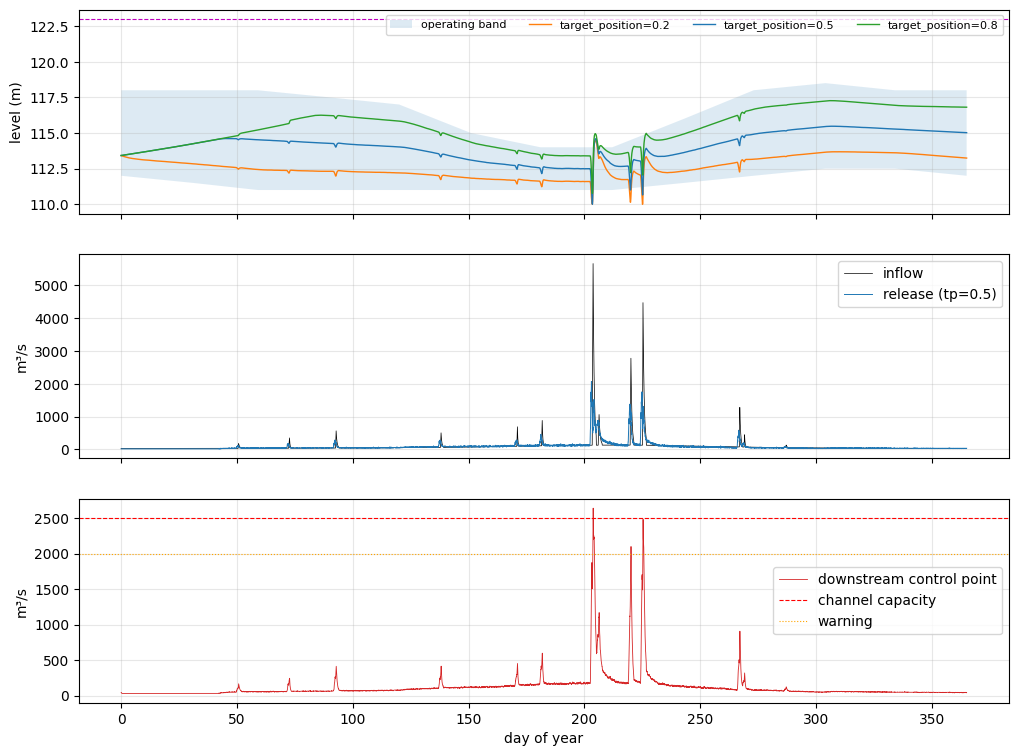

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
lg = logs[0.5]
axes[0].fill_between(lg.doy, lg.lower, lg.upper, alpha=.15, label="operating band")
for tp, c in zip((0.2, 0.5, 0.8), ("tab:orange", "tab:blue", "tab:green")):
    axes[0].plot(logs[tp].doy, logs[tp].level, c=c, lw=1, label=f"target_position={tp}")
axes[0].axhline(hr.Z_DESIGN_FLOOD, c="m", ls="--", lw=.8); axes[0].set_ylabel("level (m)"); axes[0].legend(ncol=4, fontsize=8)
axes[1].plot(lg.doy, lg.inflow, "k", lw=.5, label="inflow"); axes[1].plot(lg.doy, lg.release, c="tab:blue", lw=.7, label="release (tp=0.5)"); axes[1].legend(); axes[1].set_ylabel("m³/s")
axes[2].plot(lg.doy, lg.ds_flow, c="tab:red", lw=.6, label="downstream control point"); axes[2].axhline(hr.Q_DS_SAFE, c="r", ls="--", lw=.8, label="channel capacity"); axes[2].axhline(hr.Q_DS_WARN, c="orange", ls=":", lw=.8, label="warning"); axes[2].legend(); axes[2].set_ylabel("m³/s"); axes[2].set_xlabel("day of year")
for a in axes: a.grid(alpha=.3)

### 홍수 사상 확대

가장 큰 유입 사상 주변 5일을 확대해 마스크가 방류를 어떻게 제한했는지, 그리고 완화된 층이 있었는지 봅니다.

hours with a relaxed mask layer in this window: {'band': 14, 'ramp': 1}


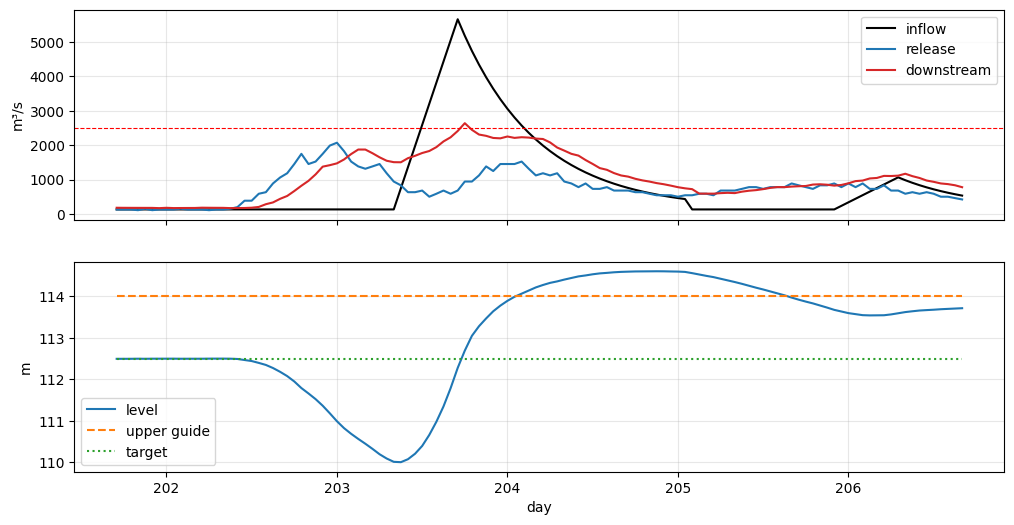

In [6]:
peak = int(lg.inflow.idxmax()); w = slice(max(peak - 48, 0), peak + 72)
seg = lg.iloc[w]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(seg.t / 24, seg.inflow, "k", label="inflow"); axes[0].plot(seg.t / 24, seg.release, c="tab:blue", label="release"); axes[0].plot(seg.t / 24, seg.ds_flow, c="tab:red", label="downstream"); axes[0].axhline(hr.Q_DS_SAFE, c="r", ls="--", lw=.8); axes[0].legend(); axes[0].set_ylabel("m³/s")
axes[1].plot(seg.t / 24, seg.level_next, label="level"); axes[1].plot(seg.t / 24, seg.upper, ls="--", label="upper guide"); axes[1].plot(seg.t / 24, seg.target, ls=":", label="target"); axes[1].legend(); axes[1].set_ylabel("m"); axes[1].set_xlabel("day")
for a in axes: a.grid(alpha=.3)
print("hours with a relaxed mask layer in this window:", seg.mask_relaxed.replace("", np.nan).dropna().value_counts().to_dict())

## 정리

* 마스크는 **홍수 > 가뭄 > 변화율** 순으로 하드 제약을 보장하고, 발전은 어디에도 없습니다.
* 규칙 베이스라인은 밴드 준수율이 높지만 홍수 시 상한 초과와 방류 급변이 생깁니다. 다음 노트북에서 PPO-Lagrangian 정책을 학습해 비교합니다.
* `summarize()` 의 지표 순서가 곧 운영기관의 우선순위입니다: 홍수 → 가뭄 → 밴드 준수 → 발전.